<a href="https://colab.research.google.com/github/semanrbingl/ai-ecommerce-product-generator/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print(path)
DATA_DIR = path

100%|██████████| 565M/565M [00:10<00:00, 55.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [3]:
DATA_DIR = "/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1"

In [4]:
import os
print("Klasör var mı:", os.path.exists(DATA_DIR))
print(os.listdir(DATA_DIR))

Klasör var mı: True
['myntradataset', 'images', 'styles.csv']


In [5]:
import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, "styles.csv"), on_bad_lines="skip")
print("Şekil:", df.shape)
df.head()

Şekil: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
usage,317
season,21
baseColour,15
productDisplayName,7
year,1
id,0
gender,0
articleType,0
masterCategory,0
subCategory,0


In [8]:
df.value_counts()

,,,,,,,,,,count
id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,
60000,Women,Apparel,Topwear,Kurtas,Blue,Fall,2012.0,Ethnic,Alma Women Blue Kurta,1
1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011.0,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,1
1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015.0,Sports,Nike Men Blue T20 Indian Cricket Jersey,1
1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013.0,Sports,Nike Mean Team India Cricket Jersey,1
1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010.0,Casual,Puma Deck Navy Blue Backpack,1
...,...,...,...,...,...,...,...,...,...,...
1539,Men,Apparel,Topwear,Tshirts,Grey,Fall,2010.0,Casual,Puma Men Ferrari Grey T-shirt,1
1540,Men,Apparel,Topwear,Tshirts,Blue,Fall,2010.0,Casual,Puma Men Ferrari Vintage Black Polo T-shirt,1
1541,Men,Footwear,Shoes,Sports Shoes,White,Fall,2010.0,Sports,Puma Men's Ballistic Spike White Green Shoe,1


In [9]:
df["articleType"].value_counts(25)

,proportion
articleType,
Tshirts,0.159081
Shirts,0.072416
Casual Shoes,0.064042
Watches,0.057221
Sports Shoes,0.045831
...,...
Cushion Covers,0.000023
Mens Grooming Kit,0.000023
Body Wash and Scrub,0.000023


In [10]:
counts = df["articleType"].value_counts()
counts.head(25)

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [11]:
# bu adımda görselleri tabloya bağla ve var mı diye kontrol et
df["image_path"] = df["id"].astype(str).apply(
    lambda x: os.path.join(DATA_DIR, "images", x + ".jpg")
)
df ["image_exists"] = df["image_path"].apply(os.path.exists)
print("Görseli olan ürün:", df["image_exists"].sum())
print("Görseli olmayan ürün:", (~df["image_exists"]).sum())

# bu adımda görseli olmayanları çıkar
df = df[df["image_exists"]].reset_index(drop=True)

# bu adımda ilk 20 sınıfı seç
TOP_N = 20
MIN_SAMPLES = 500

counts = df["articleType"].value_counts()
top_classes = counts.head(TOP_N)
top_classes = top_classes[top_classes >= MIN_SAMPLES].index.tolist()

df_model = df[df["articleType"].isin(top_classes)].reset_index(drop=True)
print("Seçilen sınıf sayısı:", len(top_classes))
print("Toplam görsel:", len(df_model))

Görseli olan ürün: 44419
Görseli olmayan ürün: 5
Seçilen sınıf sayısı: 20
Toplam görsel: 33142


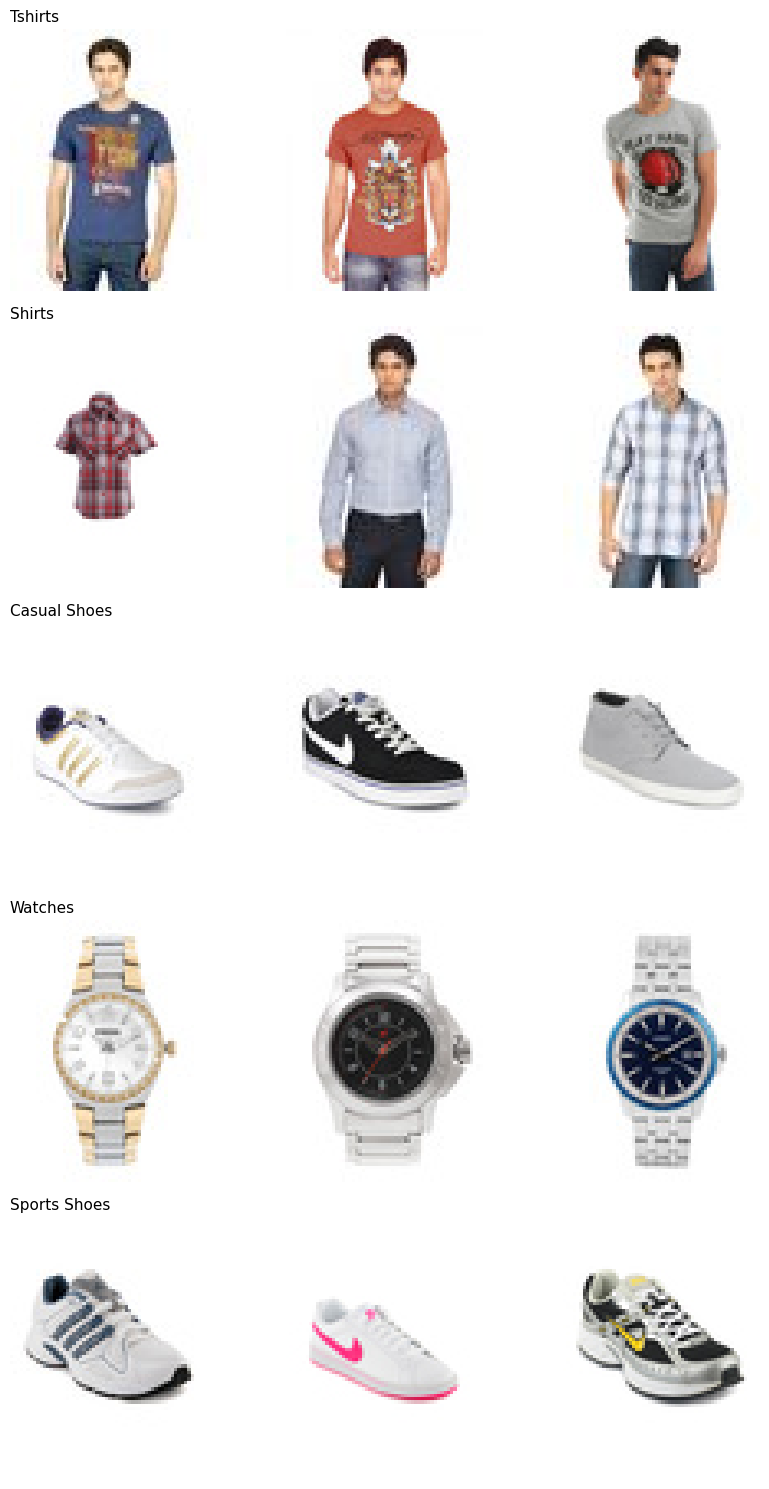

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(dataframe, n_per_class=3, classes=None):
  classes = classes or dataframe["articleType"].unique()[:5]
  fig, axes = plt.subplots(len(classes), n_per_class,
                           figsize=(3 * n_per_class, 3 * len(classes)))
  for i, cls in enumerate(classes):
    rows = dataframe[dataframe["articleType"] == cls].sample(n_per_class, random_state=42)
    for j, (_, row) in enumerate(rows.iterrows()):
      axes[i, j].imshow(Image.open(row["image_path"]).convert("RGB"))
      axes[i, j].axis("off")
      if j == 0:
        axes[i, j].set_title(cls, loc="left", fontsize=11)
  plt.tight_layout()
  plt.show()

show_samples(df_model, n_per_class=3,  classes=top_classes[:5])

In [13]:
sample = df_model.sample(200, random_state=42)
sizes = [Image.open(p).size for p in sample ["image_path"]]
size_df = pd.DataFrame(sizes, columns=["width", "height"])
size_df.describe()

,width,height
count,200.0,200.0
mean,60.0,80.0
std,0.0,0.0
min,60.0,80.0
25%,60.0,80.0
50%,60.0,80.0
75%,60.0,80.0
max,60.0,80.0
